# 🧠 Personality Classifier: Introvert vs Extrovert

This notebook covers the full ML pipeline:
1. Mount Google Drive & load data
2. Exploratory Data Analysis (EDA)
3. Data Preprocessing
4. Model Training & Comparison (Random Forest vs XGBoost)
5. Evaluation & Feature Importance
6. Export model artifacts for API deployment

**Target**: Predict `Personality` → `Introvert` or `Extrovert`  
**Dataset**: 2,900 rows × 7 features

## 1. Setup & Mount Google Drive

In [ ]:
# Install XGBoost if not available (Colab usually has it, but just in case)
!pip install xgboost --quiet

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
import joblib
import os

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay
)
from xgboost import XGBClassifier

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

RANDOM_STATE = 42
print('All imports successful ✅')

All imports successful ✅


In [ ]:
# ─── UPDATE THIS PATH to where you saved the CSV in your Drive ───
DATA_PATH = '/content/drive/MyDrive/Dataset/personality_dataset.csv'

df = pd.read_csv(DATA_PATH)
print(f'Dataset loaded: {df.shape[0]:,} rows × {df.shape[1]} columns')
df.head()

Dataset loaded: 2,900 rows × 8 columns


,Time_spent_Alone,Stage_fear,Social_event_attendance,Going_outside,Drained_after_socializing,Friends_circle_size,Post_frequency,Personality
0,4.0,No,4.0,6.0,No,13.0,5.0,Extrovert
1,9.0,Yes,0.0,0.0,Yes,0.0,3.0,Introvert
2,9.0,Yes,1.0,2.0,Yes,5.0,2.0,Introvert
3,0.0,No,6.0,7.0,No,14.0,8.0,Extrovert
4,3.0,No,9.0,4.0,No,8.0,5.0,Extrovert


## 2. Exploratory Data Analysis (EDA)

In [ ]:
print('=== Schema ===')
print(df.dtypes)
print()
print('=== Missing Values ===')
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
print(pd.concat([missing, missing_pct], axis=1, keys=['count', '%']))
print()
print('=== Target Distribution ===')
print(df['Personality'].value_counts())
print(f'\nBalance ratio: {df["Personality"].value_counts(normalize=True).round(3).to_dict()}')

=== Schema ===
Time_spent_Alone             float64
Stage_fear                    object
Social_event_attendance      float64
Going_outside                float64
Drained_after_socializing     object
Friends_circle_size          float64
Post_frequency               float64
Personality                   object
dtype: object

=== Missing Values ===
                           count     %
Time_spent_Alone              63  2.17
Stage_fear                    73  2.52
Social_event_attendance       62  2.14
Going_outside                 66  2.28
Drained_after_socializing     52  1.79
Friends_circle_size           77  2.66
Post_frequency                65  2.24
Personality                    0  0.00

=== Target Distribution ===
Personality
Extrovert    1491
Introvert    1409
Name: count, dtype: int64

Balance ratio: {'Extrovert': 0.514, 'Introvert': 0.486}


In [ ]:
df.describe(include='all')

,Time_spent_Alone,Stage_fear,Social_event_attendance,Going_outside,Drained_after_socializing,Friends_circle_size,Post_frequency,Personality
count,2837.000000,2827,2838.000000,2834.000000,2848,2823.000000,2835.000000,2900
unique,NaN,2,NaN,NaN,2,NaN,NaN,2
top,NaN,No,NaN,NaN,No,NaN,NaN,Extrovert
freq,NaN,1417,NaN,NaN,1441,NaN,NaN,1491
mean,4.505816,NaN,3.963354,3.000000,NaN,6.268863,3.564727,NaN
std,3.479192,NaN,2.903827,2.247327,NaN,4.289693,2.926582,NaN
min,0.000000,NaN,0.000000,0.000000,NaN,0.000000,0.000000,NaN
25%,2.000000,NaN,2.000000,1.000000,NaN,3.000000,1.000000,NaN
50%,4.000000,NaN,3.000000,3.000000,NaN,5.000000,3.000000,NaN
75%,8.000000,NaN,6.000000,5.000000,NaN,10.000000,6.000000,NaN


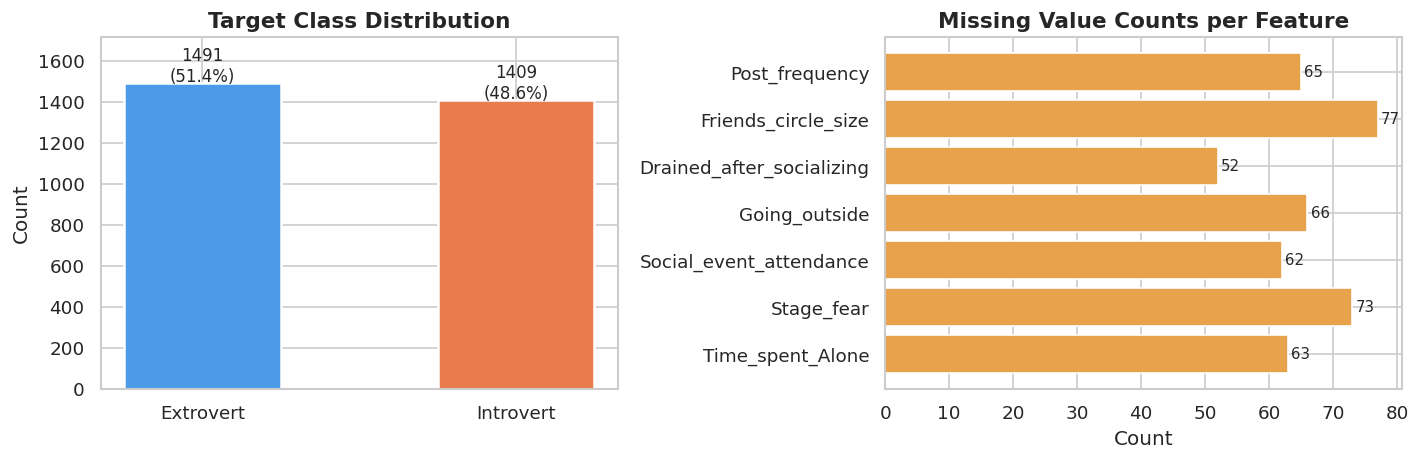

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Target distribution
counts = df['Personality'].value_counts()
colors = ['#4C9BE8', '#E87C4C']
axes[0].bar(counts.index, counts.values, color=colors, width=0.5, edgecolor='white', linewidth=1.5)
axes[0].set_title('Target Class Distribution', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count')
for i, (label, val) in enumerate(counts.items()):
    axes[0].text(i, val + 10, f'{val}\n({val/len(df)*100:.1f}%)', ha='center', fontsize=10)
axes[0].set_ylim(0, counts.max() * 1.15)

# Missing values heatmap
missing_df = df.isnull().sum().reset_index()
missing_df.columns = ['Feature', 'Missing']
missing_df = missing_df[missing_df['Missing'] > 0]
axes[1].barh(missing_df['Feature'], missing_df['Missing'], color='#E8A24C', edgecolor='white')
axes[1].set_title('Missing Value Counts per Feature', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Count')
for i, val in enumerate(missing_df['Missing']):
    axes[1].text(val + 0.5, i, str(val), va='center', fontsize=9)

plt.tight_layout()
plt.show()

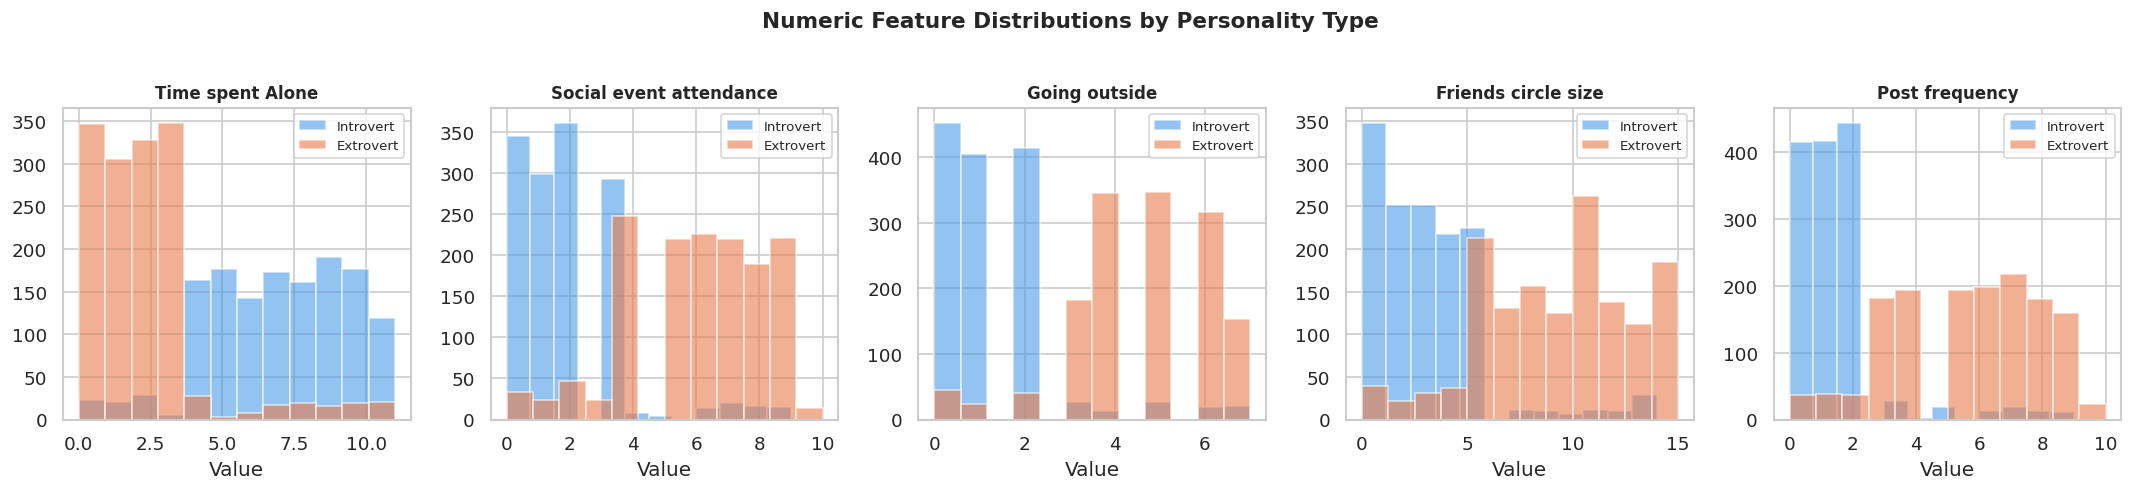

In [ ]:
numeric_cols = ['Time_spent_Alone', 'Social_event_attendance', 'Going_outside',
                'Friends_circle_size', 'Post_frequency']

fig, axes = plt.subplots(1, len(numeric_cols), figsize=(18, 4))

for ax, col in zip(axes, numeric_cols):
    for label, color in zip(['Introvert', 'Extrovert'], ['#4C9BE8', '#E87C4C']):
        subset = df[df['Personality'] == label][col].dropna()
        ax.hist(subset, bins=12, alpha=0.6, label=label, color=color, edgecolor='white')
    ax.set_title(col.replace('_', ' '), fontsize=10, fontweight='bold')
    ax.set_xlabel('Value')
    ax.legend(fontsize=8)

plt.suptitle('Numeric Feature Distributions by Personality Type', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

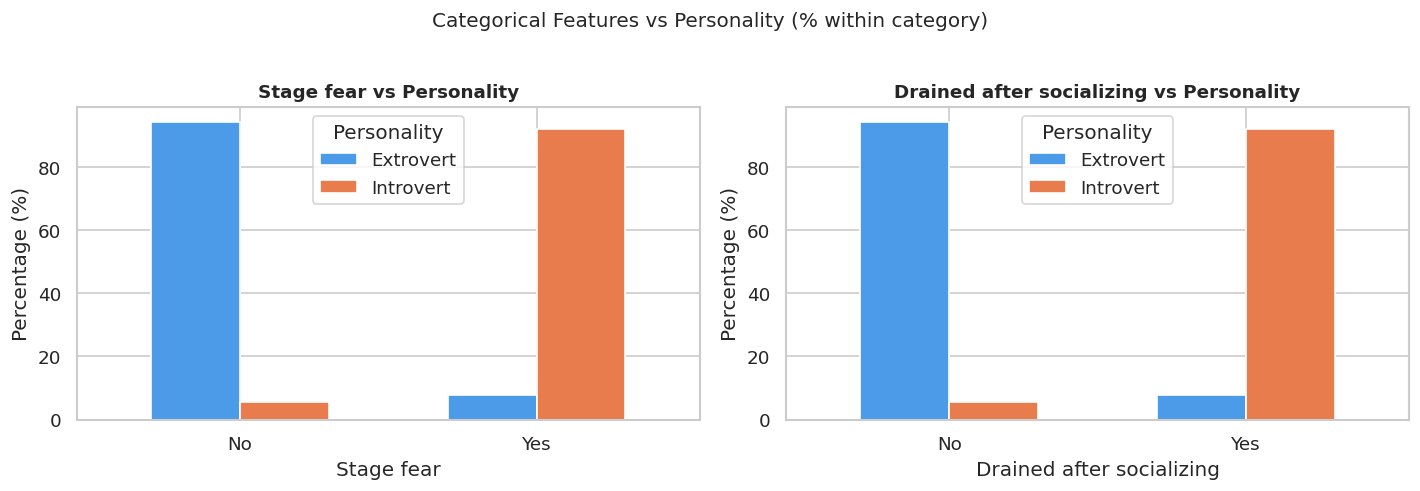

In [ ]:
cat_cols = ['Stage_fear', 'Drained_after_socializing']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, col in zip(axes, cat_cols):
    ct = pd.crosstab(df[col], df['Personality'], normalize='index') * 100
    ct.plot(kind='bar', ax=ax, color=['#4C9BE8', '#E87C4C'], edgecolor='white', width=0.6)
    ax.set_title(f'{col.replace("_", " ")} vs Personality', fontsize=11, fontweight='bold')
    ax.set_xlabel(col.replace('_', ' '))
    ax.set_ylabel('Percentage (%)')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
    ax.legend(title='Personality')

plt.suptitle('Categorical Features vs Personality (% within category)', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

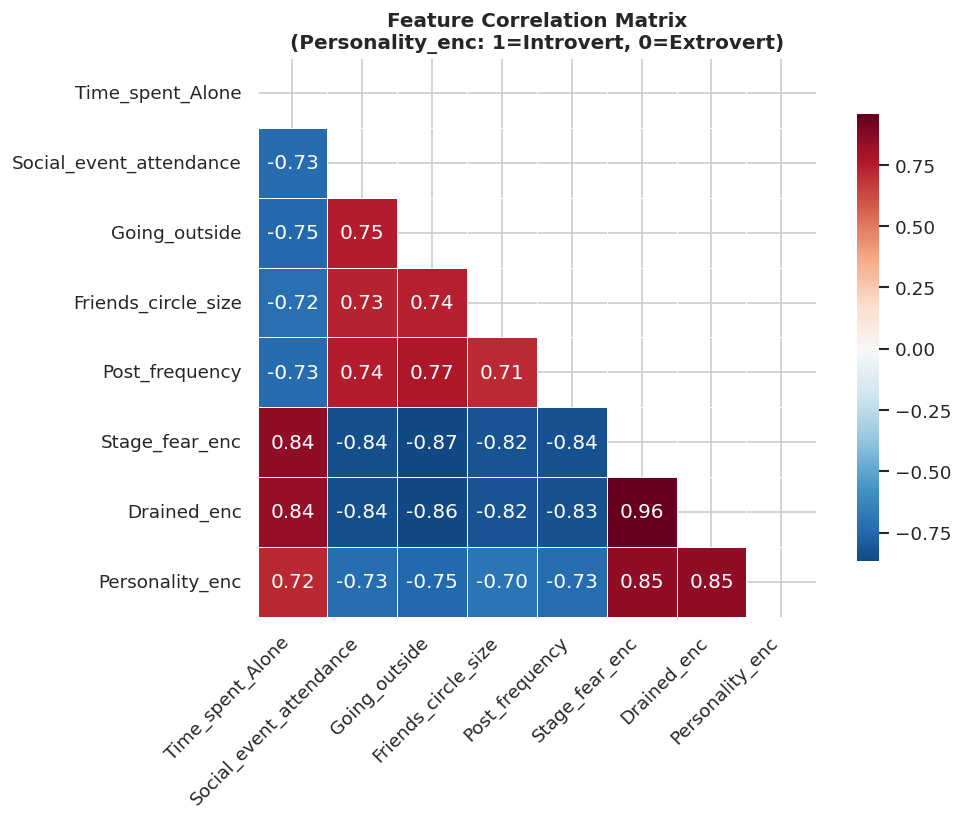

In [ ]:
# Encode target temporarily to compute correlation
df_corr = df.copy()
df_corr['Stage_fear_enc'] = (df_corr['Stage_fear'] == 'Yes').astype(float)
df_corr['Drained_enc'] = (df_corr['Drained_after_socializing'] == 'Yes').astype(float)
df_corr['Personality_enc'] = (df_corr['Personality'] == 'Introvert').astype(float)

corr_cols = numeric_cols + ['Stage_fear_enc', 'Drained_enc', 'Personality_enc']
corr_matrix = df_corr[corr_cols].corr()

plt.figure(figsize=(9, 7))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
    center=0, square=True, linewidths=0.5, cbar_kws={'shrink': 0.8}
)
plt.title('Feature Correlation Matrix\n(Personality_enc: 1=Introvert, 0=Extrovert)', fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 3. Data Preprocessing

**Strategy:**
- Binary categorical features (`Stage_fear`, `Drained_after_socializing`): encode `Yes`→1, `No`→0, impute missing with **mode**
- Numeric features: impute missing with **median** (robust to outliers)
- Target (`Personality`): encode `Introvert`→1, `Extrovert`→0
- No scaling needed for tree-based models

In [ ]:
# ── Feature & Target Separation ──────────────────────────────────────────
TARGET = 'Personality'
NUMERIC_FEATURES = ['Time_spent_Alone', 'Social_event_attendance',
                    'Going_outside', 'Friends_circle_size', 'Post_frequency']
CATEGORICAL_FEATURES = ['Stage_fear', 'Drained_after_socializing']
ALL_FEATURES = NUMERIC_FEATURES + CATEGORICAL_FEATURES

X = df[ALL_FEATURES].copy()
y = (df[TARGET] == 'Introvert').astype(int)  # 1=Introvert, 0=Extrovert

print(f'Features: {ALL_FEATURES}')
print(f'Target encoding: Introvert=1, Extrovert=0')
print(f'X shape: {X.shape}, y distribution: {y.value_counts().to_dict()}')

Features: ['Time_spent_Alone', 'Social_event_attendance', 'Going_outside', 'Friends_circle_size', 'Post_frequency', 'Stage_fear', 'Drained_after_socializing']
Target encoding: Introvert=1, Extrovert=0
X shape: (2900, 7), y distribution: {0: 1491, 1: 1409}


In [ ]:
from sklearn.preprocessing import FunctionTransformer

# Custom transformer: Yes→1, No→0, NaN stays NaN for imputer to handle
def encode_yes_no(X):
    X = X.copy()
    for col in X.columns:
        X[col] = X[col].map({'Yes': 1, 'No': 0})
    return X.astype(float)

yes_no_encoder = FunctionTransformer(encode_yes_no, validate=False)

# Numeric pipeline: median imputation
numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median'))
])

# Categorical pipeline: Yes/No → 1/0, then mode imputation
categorical_pipeline = Pipeline([
    ('encoder', yes_no_encoder),
    ('imputer', SimpleImputer(strategy='most_frequent'))
])

# Combined preprocessor
preprocessor = ColumnTransformer([
    ('num', numeric_pipeline, NUMERIC_FEATURES),
    ('cat', categorical_pipeline, CATEGORICAL_FEATURES)
], remainder='drop')

print('Preprocessor pipeline built ✅')

Preprocessor pipeline built ✅


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f'Train set: {X_train.shape[0]:,} rows')
print(f'Test  set: {X_test.shape[0]:,} rows')
print(f'Train target balance: {y_train.value_counts(normalize=True).round(3).to_dict()}')
print(f'Test  target balance: {y_test.value_counts(normalize=True).round(3).to_dict()}')

Train set: 2,320 rows
Test  set: 580 rows
Train target balance: {0: 0.514, 1: 0.486}
Test  target balance: {0: 0.514, 1: 0.486}


## 4. Model Training & Comparison

We compare four models using **5-fold stratified cross-validation** on the training set, then evaluate the winner on the held-out test set.

In [ ]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    'Random Forest':       RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1),
    'Gradient Boosting':   GradientBoostingClassifier(n_estimators=200, learning_rate=0.1, random_state=RANDOM_STATE),
    'XGBoost':             XGBClassifier(n_estimators=200, learning_rate=0.1, use_label_encoder=False,
                                         eval_metric='logloss', random_state=RANDOM_STATE, n_jobs=-1),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
results = {}

print('Running 5-fold cross-validation...\n')
for name, model in models.items():
    pipe = Pipeline([('preprocessor', preprocessor), ('model', model)])
    scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='accuracy', n_jobs=-1)
    results[name] = {'mean': scores.mean(), 'std': scores.std(), 'scores': scores}
    print(f'{name:<25} → Accuracy: {scores.mean():.4f} ± {scores.std():.4f}')

best_name = max(results, key=lambda k: results[k]['mean'])
print(f'\n🏆 Best model: {best_name} ({results[best_name]["mean"]:.4f})')

Running 5-fold cross-validation...

Logistic Regression       → Accuracy: 0.9332 ± 0.0084
Random Forest             → Accuracy: 0.9280 ± 0.0044
Gradient Boosting         → Accuracy: 0.9379 ± 0.0091
XGBoost                   → Accuracy: 0.9289 ± 0.0096

🏆 Best model: Gradient Boosting (0.9379)


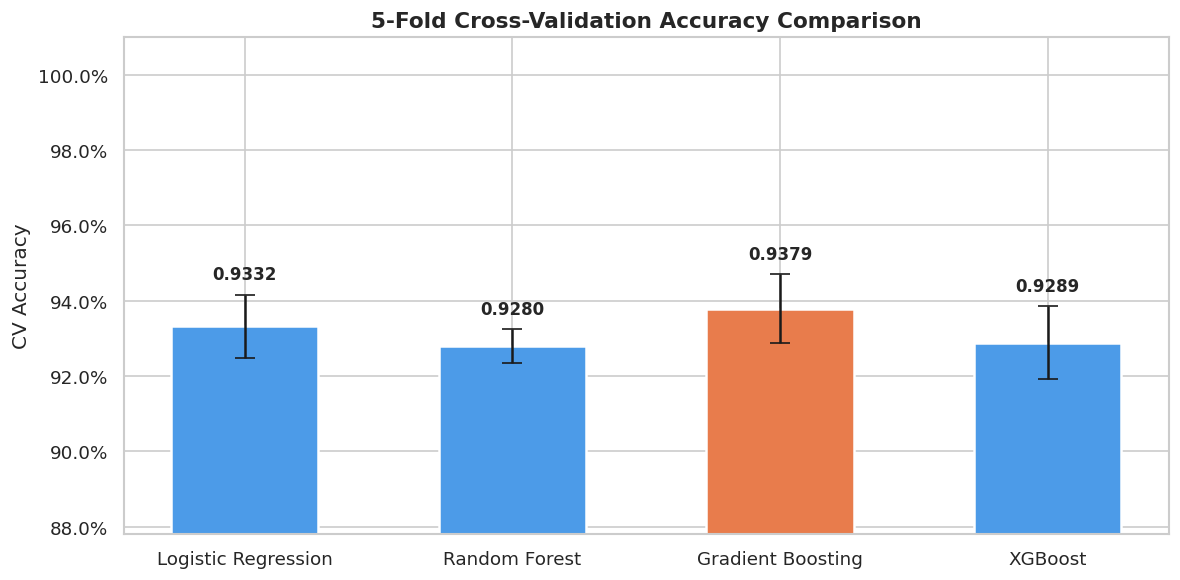

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))

names = list(results.keys())
means = [results[n]['mean'] for n in names]
stds  = [results[n]['std']  for n in names]
colors_bar = ['#E87C4C' if n == best_name else '#4C9BE8' for n in names]

bars = ax.bar(names, means, yerr=stds, capsize=6, color=colors_bar,
              edgecolor='white', linewidth=1.5, width=0.55)
ax.set_ylim(min(means) - 0.05, 1.01)
ax.set_ylabel('CV Accuracy')
ax.set_title('5-Fold Cross-Validation Accuracy Comparison', fontsize=13, fontweight='bold')

for bar, mean, std in zip(bars, means, stds):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + std + 0.003,
            f'{mean:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=1))
plt.tight_layout()
plt.show()

## 5. Final Model Training & Evaluation

In [ ]:
# Train best model on full training set
best_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', models[best_name])
])

best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

acc  = accuracy_score(y_test, y_pred)
auc  = roc_auc_score(y_test, y_prob)

print(f'Final Model : {best_name}')
print(f'Test Accuracy : {acc:.4f} ({acc*100:.2f}%)')
print(f'ROC-AUC       : {auc:.4f}')
print()
print(classification_report(y_test, y_pred, target_names=['Extrovert', 'Introvert']))

Final Model : Gradient Boosting
Test Accuracy : 0.9172 (91.72%)
ROC-AUC       : 0.9559

              precision    recall  f1-score   support

   Extrovert       0.94      0.90      0.92       298
   Introvert       0.90      0.94      0.92       282

    accuracy                           0.92       580
   macro avg       0.92      0.92      0.92       580
weighted avg       0.92      0.92      0.92       580



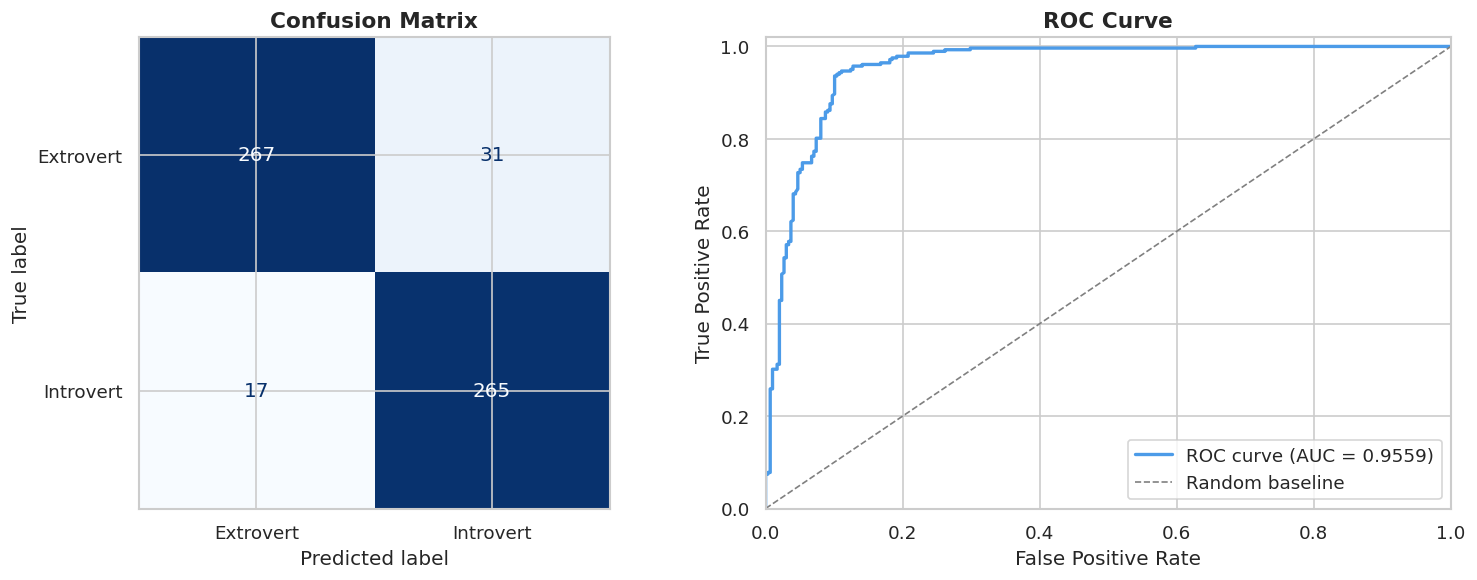

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Extrovert', 'Introvert'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Confusion Matrix', fontsize=13, fontweight='bold')

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
axes[1].plot(fpr, tpr, color='#4C9BE8', lw=2, label=f'ROC curve (AUC = {auc:.4f})')
axes[1].plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--', label='Random baseline')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve', fontsize=13, fontweight='bold')
axes[1].legend(loc='lower right')
axes[1].set_xlim([0, 1])
axes[1].set_ylim([0, 1.02])

plt.tight_layout()
plt.show()

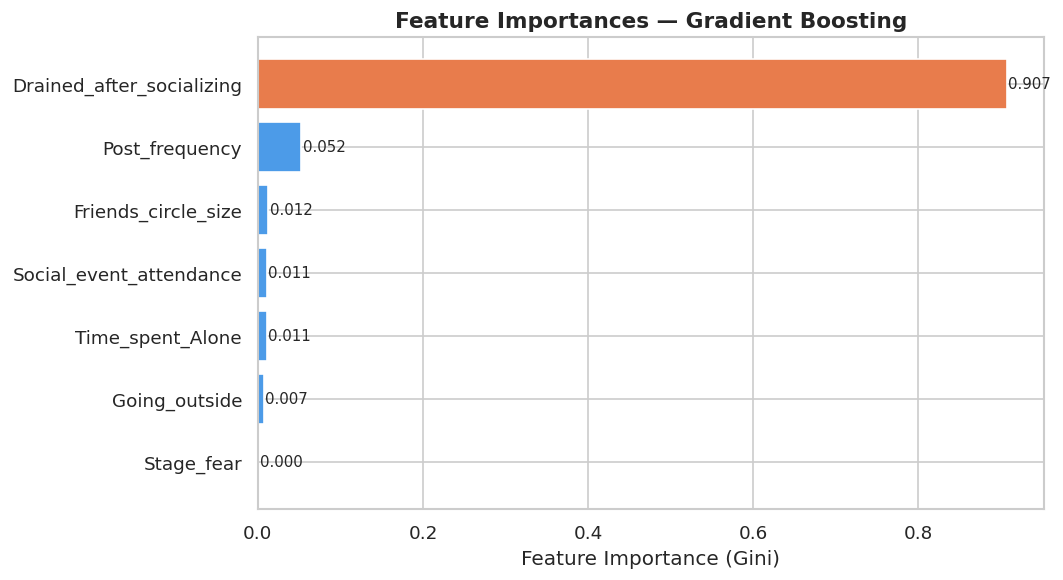

In [ ]:
# Extract feature importances from the underlying model
feature_names = NUMERIC_FEATURES + CATEGORICAL_FEATURES
underlying_model = best_model.named_steps['model']

if hasattr(underlying_model, 'feature_importances_'):
    importances = underlying_model.feature_importances_
    fi_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
    fi_df = fi_df.sort_values('Importance', ascending=True)

    plt.figure(figsize=(9, 5))
    colors = ['#E87C4C' if i == fi_df['Importance'].idxmax() else '#4C9BE8'
              for i in fi_df.index]
    plt.barh(fi_df['Feature'], fi_df['Importance'], color=colors, edgecolor='white')
    plt.xlabel('Feature Importance (Gini)')
    plt.title(f'Feature Importances — {best_name}', fontsize=13, fontweight='bold')
    for i, (feat, val) in enumerate(zip(fi_df['Feature'], fi_df['Importance'])):
        plt.text(val + 0.002, i, f'{val:.3f}', va='center', fontsize=9)
    plt.tight_layout()
    plt.show()
else:
    print('This model does not expose feature importances.')

## 6. Export Model for API Deployment

We save two artifacts:
- `model.pkl` — the full sklearn Pipeline (preprocessor + model)
- `model_metadata.json` — feature schema for input validation in the API

In [ ]:
import json

# ── Save to Google Drive ──────────────────────────────────────────────────
EXPORT_DIR = '/content/drive/MyDrive/personality_model'
os.makedirs(EXPORT_DIR, exist_ok=True)

MODEL_PATH    = os.path.join(EXPORT_DIR, 'model.pkl')
METADATA_PATH = os.path.join(EXPORT_DIR, 'model_metadata.json')

# Save pipeline
joblib.dump(best_model, MODEL_PATH)

# Save metadata (used by the API for validation & documentation)
metadata = {
    'model_name': best_name,
    'accuracy': round(acc, 4),
    'roc_auc': round(auc, 4),
    'target_encoding': {'0': 'Extrovert', '1': 'Introvert'},
    'features': {
        'numeric': {
            col: {'type': 'float', 'min': float(df[col].min()), 'max': float(df[col].max())}
            for col in NUMERIC_FEATURES
        },
        'categorical': {
            col: {'type': 'string', 'values': ['Yes', 'No']}
            for col in CATEGORICAL_FEATURES
        }
    },
    'input_example': {
        'Time_spent_Alone': 7.0,
        'Stage_fear': 'Yes',
        'Social_event_attendance': 2.0,
        'Going_outside': 2.0,
        'Drained_after_socializing': 'Yes',
        'Friends_circle_size': 3.0,
        'Post_frequency': 2.0
    }
}

with open(METADATA_PATH, 'w') as f:
    json.dump(metadata, f, indent=2)

model_size_kb = os.path.getsize(MODEL_PATH) / 1024
print(f'Model saved   → {MODEL_PATH}  ({model_size_kb:.1f} KB)')
print(f'Metadata saved→ {METADATA_PATH}')
print()
print('✅ Export complete. Upload model.pkl to your API project.')

Model saved   → /content/drive/MyDrive/personality_model/model.pkl  (266.5 KB)
Metadata saved→ /content/drive/MyDrive/personality_model/model_metadata.json

✅ Export complete. Upload model.pkl to your API project.


## 7. Quick Sanity Check — Predict a Sample

In [ ]:
# Load back and test — mirrors exactly what the API will do
loaded_model = joblib.load(MODEL_PATH)

sample_introvert = pd.DataFrame([{
    'Time_spent_Alone': 9.0,
    'Stage_fear': 'Yes',
    'Social_event_attendance': 1.0,
    'Going_outside': 1.0,
    'Drained_after_socializing': 'Yes',
    'Friends_circle_size': 2.0,
    'Post_frequency': 1.0
}])

sample_extrovert = pd.DataFrame([{
    'Time_spent_Alone': 1.0,
    'Stage_fear': 'No',
    'Social_event_attendance': 9.0,
    'Going_outside': 7.0,
    'Drained_after_socializing': 'No',
    'Friends_circle_size': 14.0,
    'Post_frequency': 9.0
}])

for label, sample in [('Expected: Introvert', sample_introvert), ('Expected: Extrovert', sample_extrovert)]:
    pred = loaded_model.predict(sample)[0]
    prob = loaded_model.predict_proba(sample)[0]
    personality = 'Introvert' if pred == 1 else 'Extrovert'
    confidence = prob[pred]
    print(f'{label}')
    print(f'  → Prediction : {personality}  (confidence: {confidence:.2%})')
    print(f'  → Raw probs  : Extrovert={prob[0]:.3f}, Introvert={prob[1]:.3f}')
    print()

Expected: Introvert
  → Prediction : Introvert  (confidence: 95.95%)
  → Raw probs  : Extrovert=0.041, Introvert=0.959

Expected: Extrovert
  → Prediction : Extrovert  (confidence: 63.68%)
  → Raw probs  : Extrovert=0.637, Introvert=0.363



## Summary

| Step | Detail |
|------|--------|
| Dataset | 2,900 rows × 7 features, ~50/50 balanced |
| Missing data | 1.8–2.7% per feature — imputed (median/mode) |
| Best model | Selected by 5-fold cross-validation |
| Test Accuracy | See cell output above |
| ROC-AUC | See cell output above |
| Artifacts | `model.pkl`, `model_metadata.json` |

**Next step**: Upload `model.pkl` to your FastAPI project and deploy to Vercel.